# E-Commerce Product Review Analysis & Rating Prediction

In [1]:
!pip install -q "transformers==4.45.0" tf-keras

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 47.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 39.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.20.0 requires huggingface-hub<2.0,>=1.2.0, but you have huggingface-hub 0.36.2 which is incompatible.


In [ ]:
import os
# Force TensorFlow to use legacy Keras 2 behavior required for compatibility with certain Hub/Transformers modules
os.environ["TF_USE_LEGACY_KERAS"] = "1"

import tensorflow as tf
print("Active TF Version:", tf.__version__)

from transformers.utils import is_tf_available

print(is_tf_available())

Active TF Version: 2.20.0
True


In [3]:
pip install cupy-cuda12x

In [4]:
pip install -U spacy

In [5]:
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 69.6 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [6]:
!pip install keras-tuner -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/129.4 kB ? eta -:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 6.6 MB/s eta 0:00:00


In [7]:
!pip install wandb -q

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import spacy
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
import tensorflow_hub as hub
from tensorflow.keras import layers
from tensorflow.keras.layers import TextVectorization, StringLookup, CategoryEncoding,  Embedding, Flatten, Conv1D, GlobalMaxPooling1D
from tensorflow.keras.layers import Input, Dense, Concatenate, Dropout, BatchNormalization, Bidirectional, LSTM, SpatialDropout1D, MaxPooling1D
from tensorflow.keras.models import Model
from tensorflow.keras import models
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import regularizers
from sklearn.utils.class_weight import compute_sample_weight
import keras_tuner as kt
import wandb
from wandb.integration.keras import WandbMetricsLogger
import keras
import imblearn
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from transformers import AutoTokenizer, TFAutoModel



Authenticate and download dataset from Kaggle competition storage

In [9]:
kagglehub.login()

Kaggle credentials set.
Kaggle credentials successfully validated.


In [10]:
path = kagglehub.competition_download('final-project-danit-ds-5-6')

print("Path to competition files:", path)

100%|██████████| 2.85M/2.85M [00:00<00:00, 99.8MB/s]

Extracting files...
Path to competition files: /root/.cache/kagglehub/competitions/final-project-danit-ds-5-6


## SECTION 1: BAG-OF-WORDS (BoW) & DENSE MULTI-OUTPUT MODEL

Read raw datasets

In [9]:
df = pd.read_csv("/root/.cache/kagglehub/competitions/final-project-danit-ds-5-6/train.csv")
test_df = pd.read_csv("/root/.cache/kagglehub/competitions/final-project-danit-ds-5-6/test.csv")

In [10]:
MAX_TOKEN = 4000
MAX_LENGTH =110

In [11]:
#Drop duplicates
df = df.drop_duplicates()
#Drop "ghost" rows
feature_cols = ['Review_Title', 'Review', 'Division', 'Department', 'Product_Category']
df = df.dropna(subset=feature_cols, how='all')
#Make the rating from 0 to 4
rating_mapping = {1:0, 2:1, 3:2, 4:3, 5:4}

if df['Rating'].max() == 5:
  df['Rating'] = df['Rating'].map(rating_mapping)

In [ ]:
#Initialize spaCy GPU context and model pipeline (disable unused components for speed)
spacy.require_gpu()
nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])

# Define domain-specific stop words and negations to preserve key sentiment signals
my_stop_words = ['clothe', 'wear', 'fabric', 'color', 'ordered', 'shirt', 'bought', 'sweater', 'looks', 'material', 'jeans', 'colors']
negations = {'no', 'not', 'never', 'neither', 'nor', 'hardly'}

def df_prepairing(df):
  """
  Cleans textual data using spaCy lemmatization while preserving sentiment negations.
  Engineers metadata indicator flags and applies log transformation to skewed continuous features.
  """
  df_copy = df.copy(deep=True)
  #Drop 'Id' column
  df_copy = df_copy.drop(columns='Id')

  #Create feature flags
  df_copy['Has_review'] = df_copy['Review'].notna().astype(int)
  df_copy['Has_feedback'] = (df_copy['Pos_Feedback_Cnt'] > 0).astype(int)
  #Fill missing values in CATEGORICAL product descriptions
  df_copy[['Division',	'Department', 'Product_Category']] = df_copy[['Division',	'Department', 'Product_Category']].fillna('miss')
  #Drop high-correlation column
  df_copy = df_copy.drop(columns='Department')
  #Apply Log Transformations
  df_copy['Pos_Feedback_Cnt'] = np.log1p(df_copy['Pos_Feedback_Cnt'])
  #Combine text and drop original text columns
  df_copy['Review_Title'] = df_copy['Review_Title'].fillna('')
  df_copy['Review'] = df_copy['Review'].fillna('no_review')

  df_copy['Full_text'] = df_copy['Review_Title'] + ' ' + df_copy['Review']
  df_copy = df_copy.drop(columns=['Review_Title', 'Review'])


  #Run spacy cleaning
  raw_text = df_copy['Full_text'].fillna('')

  sanitized_texts = [
    "" if str(text).strip().lower() in ['no_review', 'nan', ''] else str(text)
    for text in raw_text
    ]

  cleaned_text = []

  for doc in nlp.pipe(sanitized_texts, batch_size=256):
    if len(doc) == 0:
        cleaned_text.append('')
        continue

    clean_words = [
        token.lemma_.lower()
        for token in doc
        if not token.is_punct
        and not token.is_space
        and (not token.is_stop or token.lemma_.lower() in negations)
        and token.lemma_.lower() not in my_stop_words
    ]
    cleaned_text.append(' '.join(clean_words))


  df_copy['Full_text_clean'] = cleaned_text
  df_copy = df_copy.drop(columns='Full_text')

  return df_copy

Separate predictors and target features

In [13]:
y = df[['Recommended', 'Rating']]
X =df.drop(columns=['Recommended', 'Rating'])

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=27, stratify=df['Rating'])

Build scikit-learn preprocessing pipeline for continuous numerical scaling

In [14]:
X_train_prep = df_prepairing(X_train)
num_cols = ['Age', 'Pos_Feedback_Cnt']

In [15]:
prep_func = FunctionTransformer(df_prepairing)

scaler = ColumnTransformer([
    ('stand_scaler', StandardScaler(), num_cols)
], remainder='passthrough', verbose_feature_names_out=False).set_output(transform='pandas')

pipeline = Pipeline([
    ('prep', prep_func),
    ('scaler', scaler)
])

In [16]:
X_train_transformed = pipeline.fit_transform(X_train)
X_val_transformed = pipeline.transform(X_val)

Structuring input dictionaries for multi-input Keras models

In [17]:
X_train_dict = {'text_input': X_train_transformed['Full_text_clean'].astype(str).values,
                'cat_input': X_train_transformed['Product_Category'].astype(str).values,
                'div_input': X_train_transformed['Division'].astype(str).values,
                'num_input': X_train_transformed[['Age', 'Pos_Feedback_Cnt', 'Has_review', 'Has_feedback']].values.astype('float32')}

X_val_dict = {'text_input': X_val_transformed['Full_text_clean'].astype(str).values,
                'cat_input': X_val_transformed['Product_Category'].astype(str).values,
                'div_input': X_val_transformed['Division'].astype(str).values,
                'num_input': X_val_transformed[['Age', 'Pos_Feedback_Cnt', 'Has_review', 'Has_feedback']].values.astype('float32')}

Encode target outputs: one-hot for multi-class rating, binary array for recommendation

In [18]:
y_train_rating_oh = to_categorical(y_train['Rating'].values, num_classes=5)
y_val_rating_oh = to_categorical(y_val['Rating'].values, num_classes=5)

y_train_list = [y_train_rating_oh,
                y_train['Recommended'].values.astype('int32')]
y_val_list = [y_val_rating_oh,
              y_val['Recommended'].values.astype('int32')]

Adapt TF-IDF text vectorizer on preprocessed training corpus and One-hot encoding lookup layers for categorical features

In [ ]:
text_vectorizer = TextVectorization(
    max_tokens=MAX_TOKEN,
    standardize=None,
    split='whitespace',
    output_mode='tf_idf',
    ngrams=2
)
text_vectorizer.adapt(X_train_transformed['Full_text_clean'])

div_lookup = StringLookup(output_mode='int')
div_lookup.adapt(X_train_transformed['Division'])
div_encoder = CategoryEncoding(num_tokens=div_lookup.vocabulary_size(), output_mode='one_hot')

cat_lookup = StringLookup(output_mode='int')
cat_lookup.adapt(X_train_transformed['Product_Category'])
cat_encoder = CategoryEncoding(num_tokens=cat_lookup.vocabulary_size(), output_mode='one_hot')

Compute balanced class weights for Focal Loss calculation

In [20]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train['Rating']),
    y=y_train['Rating']
)

In [ ]:
def build_model(hp):  
  """
  Builds and compiles a multi-input, multi-output deep neural network with hyperparameter tuning.
  Outputs: Multi-class rating (softmax, focal loss) and binary recommendation (sigmoid, BCE loss).
  """
  text_input = Input((1,), dtype=tf.string, name='text_input')
  cat_input = Input((1,), dtype=tf.string, name='cat_input')
  div_input = Input((1,), dtype=tf.string, name='div_input')
  num_input = Input((4,), dtype=tf.float32, name='num_input')

  # Preprocess categorical and text branches
  prep_text = text_vectorizer(text_input)
  prep_div = div_encoder(div_lookup(div_input))
  prep_cat = cat_encoder(cat_lookup(cat_input))

  # Dense Text Feature Extraction Block
  text_drop = hp.Float('text_dropout', min_value=0.2, max_value=0.6, step=0.1)
  text_feature = Dropout(text_drop)(prep_text)

  text_units = hp.Int('text_units', min_value=16, max_value=256, step=32)
  text_lr = hp.Choice('text_lr', values=[0.1, 0.01, 0.001, 0.0001])

  text_feature = Dense(text_units, activation='relu', kernel_regularizer=regularizers.l2(text_lr))(text_feature)
  text_feature = BatchNormalization()(text_feature)

  # Concatenate representations
  combined = Concatenate()([text_feature, prep_div, prep_cat, num_input])

  # Shared Hidden Feature Layer
  shared_units = hp.Int('shared_units', min_value=16, max_value=256, step=32)
  shared_lr = hp.Choice('shared_lr', values=[0.1, 0.01, 0.001, 0.0001])
  shared_drop = hp.Float('shared_dropout', min_value=0.2, max_value=0.6, step=0.1)

  shared_features = Dense(shared_units, activation='relu', kernel_regularizer=regularizers.l2(shared_lr))(combined)
  shared_features = BatchNormalization()(shared_features)
  shared_features = Dropout(shared_drop)(shared_features)

  # Output Branch 1: Rating (5-class Softmax)
  rating_units = hp.Int('rating_units', min_value=16, max_value=256, step=32)
  rating_lr = hp.Choice('rating_lr', values=[0.1, 0.01, 0.001, 0.0001])
  rating_drop = hp.Float('rating_dropout', min_value=0.2, max_value=0.6, step=0.1)

  rating_branch = Dense(rating_units, activation='relu', kernel_regularizer=regularizers.l2(rating_lr))(shared_features)
  rating_branch = BatchNormalization()(rating_branch)
  rating_branch = Dropout(rating_drop)(rating_branch)
  rating_output = Dense(5, activation='softmax', name='rating_output')(rating_branch)

  # Output Branch 2: Recommendation (Binary Sigmoid)
  recom_units = hp.Int('recom_units', min_value=16, max_value=256, step=32)
  recom_lr = hp.Choice('recom_lr', values=[0.1, 0.01, 0.001, 0.0001])
  recom_drop = hp.Float('recom_dropout', min_value=0.2, max_value=0.6, step=0.1)

  recom_branch = Dense(recom_units, activation='relu', kernel_regularizer=regularizers.l2(recom_lr))(shared_features)
  recom_branch = BatchNormalization()(recom_branch)
  recom_branch = Dropout(recom_drop)(recom_branch)
  recom_output = Dense(1, activation='sigmoid', name='recom_output')(recom_branch)

  model = Model(
      inputs=[text_input, cat_input, div_input, num_input],
      outputs=[rating_output, recom_output]
      )

  comp_lr = hp.Choice('comp_lr', values=[0.001, 0.0001, 0.0005])

  model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=comp_lr),
              loss={
                  'rating_output': tf.keras.losses.CategoricalFocalCrossentropy(gamma=2.0, alpha=class_weights.tolist()),
                  'recom_output': tf.keras.losses.BinaryCrossentropy()
              },
              loss_weights={
                  'rating_output': 3.0,
                  'recom_output': 1.0
              },
              metrics={
                  'rating_output': ['accuracy', tf.keras.metrics.AUC(curve='PR', name='rating_pr_auc')],
                  'recom_output': ['accuracy', tf.keras.metrics.AUC(curve='PR', name='rec_pr_auc')]
              })
  return model


Initialize Hyperband tuner targeting validation PR-AUC maximization

In [22]:
tuner = kt.Hyperband(
    hypermodel=build_model,
    objective=kt.Objective("val_rating_output_rating_pr_auc", direction="max"),
    max_epochs=15,
    factor=3,
    directory='tuning_results',
    project_name='model_optimization'
)

Training callbacks

In [23]:
stop_early = tf.keras.callbacks.EarlyStopping(
    monitor='val_rating_output_rating_pr_auc',
    patience=8,
    restore_best_weights=True,
    verbose=1,
    mode='max'
)
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_rating_output_rating_pr_auc',
    factor=0.5,
    patience=2,
    verbose=1,
    mode='max',
    min_lr=1e-5,)

checkpoint_filepath = '/content/drive/MyDrive/Final-project/BoW_model.keras'
model_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_filepath,
    monitor='val_rating_output_rating_pr_auc',
    mode='max',
    save_best_only=True,
    verbose=1,
    )

Execute hyperparameter tuning loop

In [24]:
wandb.init(project="clothing-reviews-dl", name="BoW_model", config={"architecture": "BoW-MultiOutput"})

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: terentievasof (terentievasof-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [25]:
tuner.search(
    x=X_train_dict,
    y=y_train_list,
    epochs=15,
    validation_data=(X_val_dict, y_val_list),
    callbacks=[stop_early, reduce_lr, model_checkpoint,  WandbMetricsLogger()],
    verbose=1
)

Trial 30 Complete [00h 02m 06s]
val_rating_output_rating_pr_auc: 0.6528992652893066

Best val_rating_output_rating_pr_auc So Far: 0.6765720248222351
Total elapsed time: 00h 25m 11s


Extract best tuned architecture

In [26]:
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
best_model = tuner.get_best_models(num_models=1)[0]

In [33]:
best_model.save('/content/drive/MyDrive/Final-project/bow_model_1.keras')

In [27]:
best_model.evaluate(X_val_dict, y_val_list)

89/89 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 2.7239 - rating_output_accuracy: 0.6089 - rating_output_loss: 0.6794 - rating_output_rating_pr_auc: 0.6766 - recom_output_accuracy: 0.8801 - recom_output_loss: 0.2646 - recom_output_rec_pr_auc: 0.9835


[2.72394061088562,
 0.6794429421424866,
 0.26455143094062805,
 0.6089425086975098,
 0.6765720248222351,
 0.8800567984580994,
 0.9834904670715332]

Generate validation set predictions and evaluate normalized confusion matrix

89/89 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step


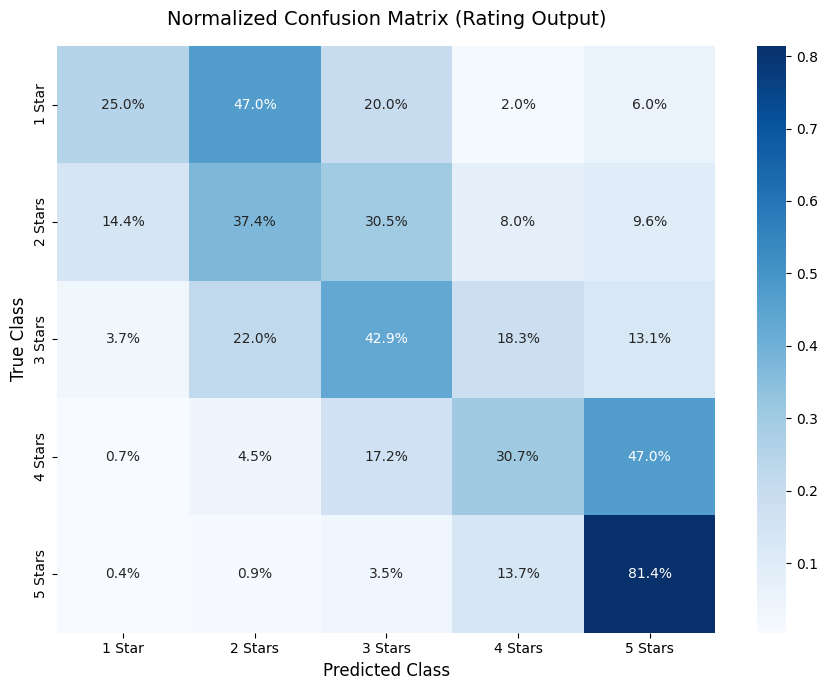


Per-Class Precision, Recall, and F1-Score:

              precision    recall  f1-score   support

      1 Star       0.33      0.25      0.28       100
     2 Stars       0.30      0.37      0.33       187
     3 Stars       0.39      0.43      0.41       350
     4 Stars       0.38      0.31      0.34       600
     5 Stars       0.79      0.81      0.80      1581

    accuracy                           0.61      2818
   macro avg       0.44      0.43      0.43      2818
weighted avg       0.60      0.61      0.60      2818



In [39]:
val_predictions = best_model.predict(X_val_dict)
rating_probs = val_predictions[0]

y_pred = np.argmax(rating_probs, axis=1)
y_true = np.argmax(y_val_list[0], axis=1)

cm_normalized = confusion_matrix(y_true, y_pred, normalize='true')

class_labels = ['1 Star', '2 Stars', '3 Stars', '4 Stars', '5 Stars']

plt.figure(figsize=(9, 7))
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt='.1%',
    cmap='Blues',
    xticklabels=class_labels,
    yticklabels=class_labels
)
plt.title('Normalized Confusion Matrix (Rating Output)', fontsize=14, pad=15)
plt.xlabel('Predicted Class', fontsize=12)
plt.ylabel('True Class', fontsize=12)
plt.tight_layout()
plt.show()


print("\nPer-Class Precision, Recall, and F1-Score:\n")
print(classification_report(y_true, y_pred, target_names=class_labels))

Inference on Kaggle test dataset

In [40]:
df_test_transformed = pipeline.transform(test_df)
X_test_dict = {'text_input': df_test_transformed['Full_text_clean'].astype(str).values,
                'cat_input': df_test_transformed['Product_Category'].astype(str).values,
                'div_input': df_test_transformed['Division'].astype(str).values,
                'num_input': df_test_transformed[['Age', 'Pos_Feedback_Cnt', 'Has_review', 'Has_feedback']].values.astype('float32')}

prediction = best_model.predict(X_test_dict)
id = test_df['Id']
prediction

294/294 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


[array([[0.08346418, 0.05843936, 0.09524389, 0.3314407 , 0.43141192],
        [0.16679972, 0.37978113, 0.3455852 , 0.08372312, 0.02411084],
        [0.0635519 , 0.02428089, 0.03111932, 0.30502352, 0.5760244 ],
        ...,
        [0.06243737, 0.01573087, 0.01034914, 0.22802342, 0.6834592 ],
        [0.05795608, 0.12672679, 0.25102666, 0.36099815, 0.20329234],
        [0.05752807, 0.10585921, 0.1941646 , 0.36290565, 0.27954254]],
       dtype=float32),
 array([[0.9794362 ],
        [0.27842316],
        [0.9910731 ],
        ...,
        [0.99011606],
        [0.90484244],
        [0.93965936]], dtype=float32)]

In [41]:
rate_prob = prediction[0]
rate_pred = np.argmax(rate_prob, axis=1) + 1

recom_prob = prediction[1]
recom_pred = (recom_prob > 0.5).astype(int).flatten()

submission_df = pd.DataFrame({
    'Id': id,
    'Rating': rate_pred,
    'Recommended': recom_pred
})

submission_df.to_csv('submission.csv', index=False)


## SECTION 2: GLOVE EMBEDDINGS + CNN-LSTM HYBRID MODEL

In [42]:
df = pd.read_csv("/root/.cache/kagglehub/competitions/final-project-danit-ds-5-6/train.csv")
test_df = pd.read_csv("/root/.cache/kagglehub/competitions/final-project-danit-ds-5-6/test.csv")

In [43]:
#Drop duplicates
df = df.drop_duplicates()
#Drop "ghost" rows
feature_cols = ['Review_Title', 'Review', 'Division', 'Department', 'Product_Category']
df = df.dropna(subset=feature_cols, how='all')
#Make the rating from 0 to 4
rating_mapping = {1:0, 2:1, 3:2, 4:3, 5:4}

if df['Rating'].max() == 5:
  df['Rating'] = df['Rating'].map(rating_mapping)

In [ ]:
def df_prepairing(df):
  """
  Clean text retaining structural punctuation signals for sequence models.
  """
  df_copy = df.copy(deep=True)
  #Drop 'Id' column
  if 'Id' in df_copy.columns:
        df_copy = df_copy.drop(columns='Id')

  #Create feature flags
  df_copy['Has_review'] = df_copy['Review'].notna().astype(int)
  df_copy['Has_feedback'] = (df_copy['Pos_Feedback_Cnt'] > 0).astype(int)

  #Fill missing categorical values
  df_copy[['Division',	'Department', 'Product_Category']] = df_copy[['Division',	'Department', 'Product_Category']].fillna('miss')

  #Drop high-correlation column
  df_copy = df_copy.drop(columns='Department')

  #Apply Log Transformations
  df_copy['Pos_Feedback_Cnt'] = np.log1p(df_copy['Pos_Feedback_Cnt'])

  #Combine Title and Review
  title = df_copy['Review_Title'].fillna('').astype(str).str.strip()
  review = df_copy['Review'].fillna('').astype(str).str.strip()

  separator = np.where((title != '') & (review != ''), '. ', '')
  full_text = title + separator + review

  df_copy['Full_text'] = full_text.str.replace(r'\s+', ' ', regex=True).str.strip()
  df_copy = df_copy.drop(columns=['Review_Title', 'Review'])


  return df_copy

In [45]:
MAX_TOKEN_LSTM = 5000
MAX_LENGTH_LSTM =110

In [46]:
y = df[['Recommended', 'Rating']]
X =df.drop(columns=['Recommended', 'Rating'])

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.1, shuffle=True, random_state=27, stratify=df['Rating'])

In [47]:
prep_func = FunctionTransformer(df_prepairing)

num_cols = ['Age', 'Pos_Feedback_Cnt']

scaler = ColumnTransformer([
    ('stand_scaler', StandardScaler(), num_cols)
], remainder='passthrough', verbose_feature_names_out=False).set_output(transform='pandas')

pipeline = Pipeline([
    ('prep', prep_func),
    ('scaler', scaler)
])

In [48]:
X_train_transformed = pipeline.fit_transform(X_train)
X_val_transformed = pipeline.transform(X_val)

Apply Hybrid Imbalance Resampling (SMOTE/Random Oversampling + Undersampling)

In [49]:
X_temp = X_train_transformed.copy(deep=True)
X_temp['Recommended'] = y_train['Recommended'].values

over_strategy={
    0: 2000,
    1: 2000,
    2: 2500,

}

under_strategy = {
    3: 2500,
    4:3000
}

combined_sample_pipeline = imblearn.pipeline.Pipeline([
    ('oversample', RandomOverSampler(random_state=21, sampling_strategy=over_strategy,)),
    ('undersample', RandomUnderSampler(random_state=21, sampling_strategy=under_strategy,))
])

X_res, y_rating_res = combined_sample_pipeline.fit_resample(X_temp, y_train['Rating'])

y_recommended_res = X_res.pop('Recommended').values
X_train_res = X_res

y_train_dict_res = {
    'Rating': y_rating_res.values,
    'Recommended': y_recommended_res
}


Construct dataset dictionary structures

In [50]:
X_train_dict = {'text_input': X_train_res['Full_text'].astype(str).values,
                'cat_input': X_train_res['Product_Category'].astype(str).values,
                'div_input': X_train_res['Division'].astype(str).values,
                'num_input': X_train_res[['Age', 'Pos_Feedback_Cnt', 'Has_review', 'Has_feedback']].values.astype('float32')}

X_val_dict = {'text_input': X_val_transformed['Full_text'].astype(str).values,
                'cat_input': X_val_transformed['Product_Category'].astype(str).values,
                'div_input': X_val_transformed['Division'].astype(str).values,
                'num_input': X_val_transformed[['Age', 'Pos_Feedback_Cnt', 'Has_review', 'Has_feedback']].values.astype('float32')}

In [ ]:
y_train_rating_oh = to_categorical(y_train_dict_res['Rating'], num_classes=5)
y_val_rating_oh = to_categorical(y_val['Rating'].values, num_classes=5)

y_train_list = [y_train_rating_oh,
                y_train_dict_res['Recommended'].astype('int32')]
y_val_list = [y_val_rating_oh,
              y_val['Recommended'].values.astype('int32')]

String Lookup adaptation for embedding indices

In [52]:
cat_stringlookup_layer = StringLookup(name='cat_lookup')
cat_stringlookup_layer.adapt(X_train_transformed['Product_Category'].astype(str).values)
cat_vocab_size = cat_stringlookup_layer.vocabulary_size()

div_stringlookup_layer = StringLookup(name='div_lookup')
div_stringlookup_layer.adapt(X_train_transformed['Division'].astype(str).values)
div_vocab_size = div_stringlookup_layer.vocabulary_size()

Custom text standardization preserving punctuation marks

In [53]:
@tf.keras.utils.register_keras_serializable()
def custom_standardization(input_data):
  lowercase = tf.strings.lower(input_data)

  spaced_punctuation = tf.strings.regex_replace(lowercase, r"([!?])", r" \1 ")

  cleaned = tf.strings.regex_replace(spaced_punctuation, r"[^0-9a-z\s!?'_]", '')
  return cleaned

In [54]:
vectorizer = TextVectorization(max_tokens=MAX_TOKEN_LSTM, standardize=custom_standardization, output_sequence_length=MAX_LENGTH_LSTM)
vectorizer.adapt(X_train_transformed['Full_text'].astype(str).values)

Download and parse GloVe 100d pretrained embeddings

In [55]:
import os
import urllib.request
import zipfile

if not os.path.exists('glove.6B.100d.txt'):
    print("Downloading GloVe 6B embeddings (approx. 822MB)...")
    url = "https://nlp.stanford.edu/data/glove.6B.zip"
    urllib.request.urlretrieve(url, "glove.6B.zip")

    print("Extracting glove.6B.100d.txt...")
    with zipfile.ZipFile("glove.6B.zip", "r") as zip_ref:
        zip_ref.extract("glove.6B.100d.txt")
    print("Ready!")
embeddings_index = {}
with open('glove.6B.100d.txt', encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embeddings_index[word] = coefs

vocab = vectorizer.get_vocabulary()
embedding_dim = 100
embedding_matrix = np.zeros((MAX_TOKEN_LSTM, embedding_dim))

for i, word in enumerate(vocab):
    if i >= MAX_TOKEN_LSTM:
        break
    embedding_vector = embeddings_index.get(word)
    if embedding_vector is not None:
        embedding_matrix[i] = embedding_vector

Extracting glove.6B.100d.txt...
Ready!


In [56]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_dict_res['Rating']),
    y=y_train_dict_res['Rating']
)

In [ ]:
def build_model_LSTM(hp):
  """
  Constructs a CNN + Bidirectional LSTM sequential deep learning model.
  Utilizes pre-trained GloVe embeddings and categorical lookup embedding layers.
  """
  text_input = Input((1,), dtype=tf.string, name='text_input')
  div_input = Input((1,), dtype=tf.string, name='div_input')
  cat_input = Input((1,), dtype=tf.string, name='cat_input')
  num_input = Input((4,), dtype=tf.float32, name="num_input")

  vectorized_text = vectorizer(text_input)

  # Static GloVe Embedding Layer
  text_layer = Embedding(
    input_dim=MAX_TOKEN_LSTM,
    output_dim=embedding_dim,
    embeddings_initializer=tf.keras.initializers.Constant(embedding_matrix),
    trainable=False,
    name="glove_embedding"
  )(vectorized_text)

  text_layer = SpatialDropout1D(0.2)(text_layer)

  # 1D-CNN + BiLSTM Feature Extractor
  text_filters = hp.Int('text_filters', min_value=32, max_value=64, step=16)
  text_kernel = hp.Int('text_kernel', min_value=3, max_value=5, step=1)
  text_units = hp.Int('text_units', min_value=16, max_value=64, step=16)
  text_rate = hp.Float('text_rate', min_value=0.2, max_value=0.5, step=0.1)

  text_layer = Conv1D(filters=text_filters, kernel_size=text_kernel, activation='relu', padding='same')(text_layer)
  text_layer = MaxPooling1D(pool_size=2)(text_layer)
  text_layer = Bidirectional(LSTM(text_units, return_sequences=True))(text_layer)
  text_layer = GlobalMaxPooling1D()(text_layer)
  text_layer = Dropout(text_rate)(text_layer)

  # Entity Embeddings for Categorical Metadata
  cat_layer = cat_stringlookup_layer(cat_input)
  cat_layer = Embedding(input_dim=cat_vocab_size, output_dim=8,)(cat_layer)
  cat_layer = Flatten()(cat_layer)

  div_layer = div_stringlookup_layer(div_input)
  div_layer = Embedding(input_dim=div_vocab_size, output_dim=4,)(div_layer)
  div_layer = Flatten()(div_layer)

  num_units = hp.Int('num_units', min_value=8, max_value=32, step=8)
  num_layer = Dense(num_units, activation='relu')(num_input)

  # Concatenate features across modal branches
  combined = layers.concatenate([num_layer, div_layer, cat_layer, text_layer])

  gen_units = hp.Int('gen_units', min_value=16, max_value=64, step=16)
  gen_rate = hp.Float('gen_rate', min_value=0.3, max_value=0.5, step=0.1)

  general_layer = Dense(gen_units, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-3))(combined)
  general_layer = BatchNormalization()(general_layer)
  general_layer = Dropout(gen_rate)(general_layer)

  recom_output = Dense(1, activation='sigmoid', name='recom_output')(general_layer)
  rating_output = Dense(5, activation='softmax', name='rating_output')(general_layer)

  model_lstm = Model(
      inputs={
          'text_input': text_input,
          'div_input': div_input,
          'cat_input': cat_input,
          'num_input': num_input
          },
      outputs=[rating_output, recom_output]
      )

  comp_lr = hp.Choice('comp_lr', values=[0.001, 0.0005])

  model_lstm.compile(
      optimizer=tf.keras.optimizers.Adam(learning_rate=comp_lr, clipnorm=1.0),
      loss={
          'rating_output': tf.keras.losses.CategoricalFocalCrossentropy(gamma=2.0, alpha=class_weights.tolist()),
          'recom_output': tf.keras.losses.BinaryCrossentropy()
      },
      loss_weights={
          'rating_output': 3.0,
          'recom_output': 1.0
      },
      metrics={
          'rating_output': ['accuracy', tf.keras.metrics.AUC(curve='PR', multi_label=True, num_labels=5, name='rating_pr_auc')],
          'recom_output': ['accuracy', tf.keras.metrics.AUC(curve='PR', num_thresholds=1000, name='rec_pr_auc')]
      })


  return model_lstm


In [58]:
tuner_lstm = kt.Hyperband(
    hypermodel=build_model_LSTM,
    objective=kt.Objective("val_rating_output_rating_pr_auc", direction="max"),
    max_epochs=45,
    factor=3,
    directory='tuning_results',
    project_name='lstm_model_optimization',
    overwrite=True
)

In [59]:
stop_early = tf.keras.callbacks.EarlyStopping(
    monitor='val_rating_output_rating_pr_auc',
    patience=6,
    restore_best_weights=True,
    verbose=1,
    mode='max'
)
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_rating_output_rating_pr_auc',
    factor=0.5,
    patience=2,
    verbose=1,
    mode='max',
    min_lr=1e-5,)

checkpoint_filepath = '/content/drive/MyDrive/Final-project/LSTM_model.keras'
model_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_filepath,
    monitor='val_rating_output_rating_pr_auc',
    mode='max',
    save_best_only=True,
    verbose=1,
    )

In [60]:
wandb.init(project="clothing-reviews-dl", name="LSTM_model", config={"architecture": "LSTM-MultiOutput"})

epoch/epoch,▁▁▂▁▂▃▂▃▂▃▇▄▆▇▂▂▂▃▂▁▃▂▃▅▆▅▆▇▇█▅▂▅▆▄▇▂▃▄▇
epoch/learning_rate,█▄█▄█▄█▄▄█▄▂▁███████▄▁▁▄▄▄▄▂▁▁▄▂▁█▄▄▂▂▄▂
epoch/loss,▄▃█▅▄▄▃▂▁▁▁▁▁▁▂▃▆▃▂▃▂▁▁▁▁▁▂▂▃▂▂▂▂▆▃▃▂▂▂▂
epoch/rating_output_accuracy,▃▂▁▂▄▆▆▇█▅▅▅▂▅▅▃▅▁▃▅▆▆▇█▁▆▇▁▄▅▄▄▄▄▅▂▃▄▄▅
epoch/rating_output_loss,▆▅▃██▄▆▃▄▃▃▃▂▂▁▂▄▄▂▄▇▅▃▃▂▂▂▁▂▅▂▂▂▅▄▄▃▃█▃
epoch/rating_output_rating_pr_auc,▁▂▂▄▅▅▇▇▄▅▁▃▁▃▅▄▅▃▄▅▇▇▇█▆▁▄▅▆▆▃▄▄▄▄▄▄▄▅▅
epoch/recom_output_accuracy,▄▆▂▅▅▄▆▄▆▇▇▇███▇▇▇▇▇▇▄▇▄████▁▇█▃▇██▆▇▆▇▇
epoch/recom_output_loss,▅▃▆▃██▃▅▅▃▂▂▁▃▂▂▂▆▃▂▃▆▆▂▁▁▁▁▄▂▆▃▃▂▂▃▃▃▂▃
epoch/recom_output_rec_pr_auc,▄▆▁▁▂▆▇▇█▇█▇▇██▇▃▆▃█▄▇▆▇███▁▇██████▁▇▇▇▇
epoch/val_loss,▅▇▅▂▁▁▁▁▁▁▄▃▅▂▁▁▂▂▂▂▂█▃▂▄▂▂▁▁▁▄▃▃▂▂▁▁▅▃▂
+6,...


In [61]:
tuner_lstm.search(
    x=X_train_dict,
    y=y_train_list,
    epochs=25,
    validation_data=(X_val_dict, y_val_list),
    callbacks=[stop_early, model_checkpoint, reduce_lr, WandbMetricsLogger()],
    batch_size=128,
    verbose=1,
    # sample_weight=[
    #      rating_sample_weights,
    #      np.ones(len(rating_labels))
    # ]
)


Trial 90 Complete [00h 02m 02s]
val_rating_output_rating_pr_auc: 0.41276565194129944

Best val_rating_output_rating_pr_auc So Far: 0.4959622323513031
Total elapsed time: 00h 50m 51s


In [62]:
best_hps = tuner_lstm.get_best_hyperparameters(num_trials=1)[0]
best_model = tuner_lstm.get_best_models(num_models=1)[0]

45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step


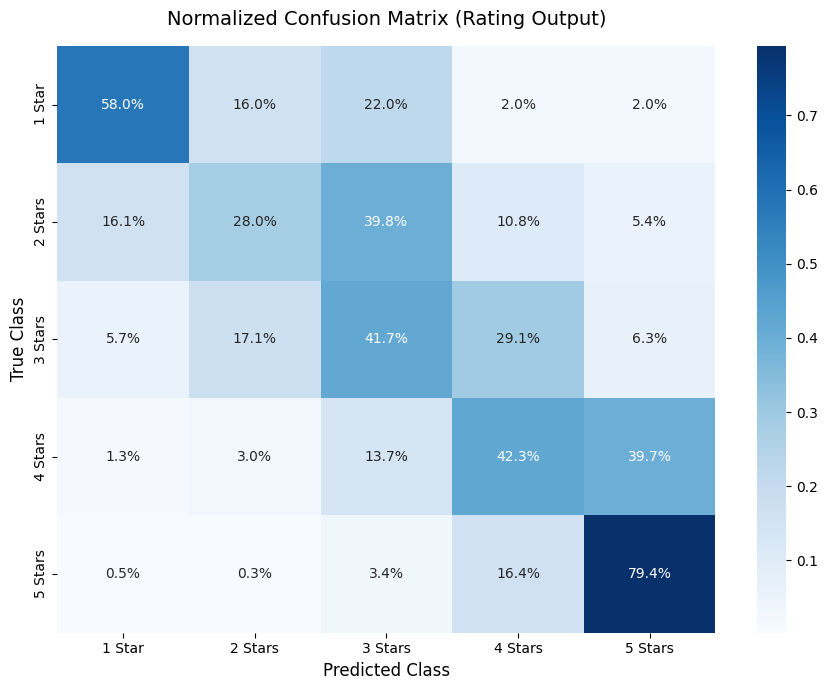


Per-Class Precision, Recall, and F1-Score:

              precision    recall  f1-score   support

      1 Star       0.47      0.58      0.52        50
     2 Stars       0.35      0.28      0.31        93
     3 Stars       0.39      0.42      0.40       175
     4 Stars       0.40      0.42      0.41       300
     5 Stars       0.82      0.79      0.81       791

    accuracy                           0.63      1409
   macro avg       0.48      0.50      0.49      1409
weighted avg       0.63      0.63      0.63      1409



In [63]:
val_predictions = best_model.predict(X_val_dict)
rating_probs = val_predictions[0]

y_pred = np.argmax(rating_probs, axis=1)
y_true = np.argmax(y_val_list[0], axis=1)

cm_normalized = confusion_matrix(y_true, y_pred, normalize='true')

class_labels = ['1 Star', '2 Stars', '3 Stars', '4 Stars', '5 Stars']

plt.figure(figsize=(9, 7))
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt='.1%',
    cmap='Blues',
    xticklabels=class_labels,
    yticklabels=class_labels
)
plt.title('Normalized Confusion Matrix (Rating Output)', fontsize=14, pad=15)
plt.xlabel('Predicted Class', fontsize=12)
plt.ylabel('True Class', fontsize=12)
plt.tight_layout()
plt.show()

# 5. Print Detailed Classification Report
print("\nPer-Class Precision, Recall, and F1-Score:\n")
print(classification_report(y_true, y_pred, target_names=class_labels))

In [64]:
best_model.evaluate(X_val_dict, y_val_list)

45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 1.4940 - rating_output_accuracy: 0.6267 - rating_output_loss: 0.4498 - rating_output_rating_pr_auc: 0.4960 - recom_output_accuracy: 0.9013 - recom_output_loss: 0.2565 - recom_output_rec_pr_auc: 0.9878


[1.4939985275268555,
 0.44976040720939636,
 0.25652697682380676,
 0.626685619354248,
 0.4959622323513031,
 0.9013484716415405,
 0.9878354072570801]

In [65]:
df_test_transformed = pipeline.transform(test_df)

X_test_dict = {'text_input': df_test_transformed['Full_text'].astype(str).values,
                'cat_input': df_test_transformed['Product_Category'].astype(str).values,
                'div_input': df_test_transformed['Division'].astype(str).values,
                'num_input': df_test_transformed[['Age', 'Pos_Feedback_Cnt', 'Has_review', 'Has_feedback']].values.astype('float32')}

prediction = best_model.predict(X_test_dict)
id = test_df['Id']
prediction

294/294 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


[array([[0.00325396, 0.00366018, 0.02325718, 0.33557776, 0.63425094],
        [0.45316568, 0.36873472, 0.1561276 , 0.01621324, 0.00575875],
        [0.00200741, 0.00284212, 0.02400247, 0.3669081 , 0.6042399 ],
        ...,
        [0.00298357, 0.00377331, 0.02501679, 0.35175455, 0.6164718 ],
        [0.0959092 , 0.29224315, 0.4634201 , 0.11814857, 0.03027898],
        [0.05302965, 0.08882177, 0.22936699, 0.35759026, 0.27119127]],
       dtype=float32),
 array([[0.9936597 ],
        [0.04708382],
        [0.99535805],
        ...,
        [0.99354774],
        [0.2962555 ],
        [0.8360068 ]], dtype=float32)]

In [66]:
rate_prob = prediction[0]
rate_pred = np.argmax(rate_prob, axis=1) + 1

recom_prob = prediction[1]
recom_pred = (recom_prob > 0.5).astype(int).flatten()

submission_df = pd.DataFrame({
    'Id': id,
    'Rating': rate_pred,
    'Recommended': recom_pred
})

submission_df.to_csv('submission.csv', index=False)

## SECTION 3: TRANSFORMER DEBERTA-V3 (TEXT LINEARIZATION)

In [10]:
df = pd.read_csv("/root/.cache/kagglehub/competitions/final-project-danit-ds-5-6/train.csv")
test_df = pd.read_csv("/root/.cache/kagglehub/competitions/final-project-danit-ds-5-6/test.csv")

In [ ]:
# Drop duplicates and blank rows
df = df.drop_duplicates()
df = df.dropna(subset=['Review_Title', 'Review', 'Division', 'Department', 'Product_Category'], how='all')

# Zero-index target rating scale (1-5 -> 0-4)
if df['Rating'].max() == 5:
    rate_map = {1: 0, 2: 1, 3: 2, 4: 3, 5: 4}
    df['Rating'] = df['Rating'].map(rate_map)

def data_prep(df):
  """
  Linearizes structured tabular attributes and unstructured text reviews into unified strings.
  This enables subword attention mechanisms across both context metadata and user review text.
  """
  df_copy = df.copy(deep=True)
  df_copy = df_copy.drop(columns=['Department', 'Id'], errors='ignore')

  # Impute missing categorical attributes
  df_copy[['Division', 'Product_Category']] = df_copy[['Division', 'Product_Category']].fillna('Unknown')

  # Clean text inputs 
  review_title = df_copy['Review_Title'].fillna('').astype(str).str.strip()
  review = df_copy['Review'].fillna('').astype(str).str.strip()

  # Construct linearized input sequence with explicit feature tags
  df_copy['Linearized_text'] = (
      "Review: " + review + ". " +
      'Title: ' + review_title + ". " +
      "Division: " + df_copy['Division'] + ". " +
      "Category: " + df_copy['Product_Category'] + ". " +
      "Helpful Feedback: " + df_copy['Pos_Feedback_Cnt'].astype(str) + ". " +
      "Age: " + df_copy['Age'].astype(str) + ". "
      )

  # Normalize whitespace
  df_copy['Linearized_text'] = df_copy['Linearized_text'].str.replace(r'\s+', ' ', regex=True).str.strip()
  return df_copy

df = data_prep(df)

Apply linearization transform to training and Kaggle test sets

In [12]:
test_df_prep = data_prep(test_df)

Stratified Train/Validation split based on target class distribution

In [22]:
train_df, val_df = train_test_split(df, test_size=0.2, random_state=27, stratify=df['Rating'])

Compute balanced class weights to address rating class imbalance in Focal Loss

In [23]:
alpha_rating_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_df['Rating']),
    y=train_df['Rating'])

In [24]:
MAX_LENGTH = 153
MODEL_NAME = "microsoft/deberta-v3-small"

Initialize pretrained subword tokenizer

In [25]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, clean_up_tokenization_spaces=True)

/usr/local/lib/python3.12/dist-packages/transformers/convert_slow_tokenizer.py:558: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


In [ ]:
def encode_text(text_series, tokenizer, max_length=MAX_LENGTH):
  """
  Encodes linearized text series into subword input IDs and attention masks for TensorFlow models.
  """
  encoded = tokenizer(
      text=text_series.tolist(),
      add_special_tokens=True,
      max_length=max_length,
      padding='max_length',
      truncation=True,
      return_attention_mask=True,
      return_tensors='tf'
  )

  return {
      'input_ids': encoded['input_ids'],
      'attention_mask': encoded['attention_mask']
  }

Tokenize training, validation, and test datasets and format multi-output target labels

In [27]:
X_train = encode_text(train_df['Linearized_text'], tokenizer)
X_val = encode_text(val_df['Linearized_text'], tokenizer)
X_test = encode_text(test_df_prep['Linearized_text'], tokenizer)

y_train = {'rating_output': tf.keras.utils.to_categorical(train_df['Rating'], num_classes=5),
           'recom_output': train_df['Recommended']}

y_val = {'rating_output': tf.keras.utils.to_categorical(val_df['Rating'], num_classes=5),
         'recom_output': val_df['Recommended']}

In [ ]:
def build_transformer_multi_output(model_name=MODEL_NAME, max_length=MAX_LENGTH):
  """
  Constructs a multi-task learning architecture backed by a DeBERTa transformer core.
  Uses mean pooling across active token positions instead of standard CLS pooling.
  """
  # Define input tensors matching Transformer expectations
  input_ids = Input((max_length,), dtype=tf.int32, name='input_ids')
  attention_mask = Input((max_length,), dtype=tf.int32, name='attention_mask')

  # Instantiate HuggingFace backbone
  transformer = TFAutoModel.from_pretrained(model_name)
  transformer.trainable=False # Freeze backbone for initial head warmup phase

  # Extract sequence output embeddings (shape: [batch_size, seq_len, hidden_dim])
  sequence_output = transformer(input_ids=input_ids, attention_mask=attention_mask)[0]

  # Custom Attention-Masked Mean Pooling
  # Zeroes out padding token embeddings before computing sequence averages
  mask = tf.cast(tf.expand_dims(attention_mask, -1), tf.float32)
  pooled_output = tf.reduce_sum(sequence_output * mask, axis=1) / tf.maximum(tf.reduce_sum(mask, axis=1), 1e-9)

  # Classification Dense Head
  x = Dropout(0.3)(pooled_output)
  x = Dense(256, activation='relu')(x)
  x = Dropout(0.2)(x)

  # Multi-Task Task Outputs
  rating_output = Dense(5, activation='softmax', name='rating_output')(x)
  recom_output = Dense(1, activation='sigmoid', name='recom_output')(x)

  model = Model(inputs={'input_ids': input_ids, 'attention_mask': attention_mask},
                outputs=[rating_output, recom_output])

  return model, transformer


Instantiate frozen backbone model for initial training phase

In [29]:
model, transformer_layer = build_transformer_multi_output()
model.summary()

All model checkpoint layers were used when initializing TFDebertaV2Model.

All the layers of TFDebertaV2Model were initialized from the model checkpoint at microsoft/deberta-v3-small.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFDebertaV2Model for predictions without further training.


Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 attention_mask (InputLayer  [(None, 153)]                0         []                            
 )                                                                                                
                                                                                                  
 input_ids (InputLayer)      [(None, 153)]                0         []                            
                                                                                                  
 tf.expand_dims_1 (TFOpLamb  (None, 153, 1)               0         ['attention_mask[0][0]']      
 da)                                                                                              
                                                                                            

In [30]:
wandb.init(project="clothing-reviews-dl", name="Transformer_model", config={"architecture": "DeBerta-MultiOutput"})

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: terentievasof (terentievasof-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Compile for Phase 1: Train classification heads only with higher learning rate

In [31]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
              loss={
                  'rating_output': tf.losses.CategoricalFocalCrossentropy(gamma=2.0, alpha=alpha_rating_weights.tolist()),
                  'recom_output': tf.losses.BinaryCrossentropy()
              },
              loss_weights={
                  'rating_output': 3.0,
                  'recom_output': 1.0
              },
              metrics={
                  'rating_output': ['accuracy', tf.keras.metrics.AUC(curve='PR', name='rating_pr_auc')],
                  'recom_output': ['accuracy', tf.keras.metrics.AUC(curve='PR', name='rec_pr_auc')]
              })

In [32]:
model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=2,
    batch_size=32,
    callbacks=WandbMetricsLogger(),
    verbose=1)

Epoch 1/2


Instructions for updating:
The TensorFlow Distributions library has moved to TensorFlow Probability (https://github.com/tensorflow/probability). You should update all references to use `tfp.distributions` instead of `tf.distributions`.
Instructions for updating:
The TensorFlow Distributions library has moved to TensorFlow Probability (https://github.com/tensorflow/probability). You should update all references to use `tfp.distributions` instead of `tf.distributions`.


353/353 [==============================] - 179s 448ms/step - loss: 2.8182 - rating_output_loss: 0.8315 - recom_output_loss: 0.3236 - rating_output_accuracy: 0.4592 - rating_output_rating_pr_auc: 0.4982 - recom_output_accuracy: 0.8618 - recom_output_rec_pr_auc: 0.9674 - val_loss: 1.8955 - val_rating_output_loss: 0.5640 - val_recom_output_loss: 0.2035 - val_rating_output_accuracy: 0.4847 - val_rating_output_rating_pr_auc: 0.5550 - val_recom_output_accuracy: 0.9155 - val_recom_output_rec_pr_auc: 0.9907
Epoch 2/2
353/353 [==============================] - 155s 438ms/step - loss: 2.1039 - rating_output_loss: 0.6254 - recom_output_loss: 0.2277 - rating_output_accuracy: 0.5560 - rating_output_rating_pr_auc: 0.6305 - recom_output_accuracy: 0.9020 - recom_output_rec_pr_auc: 0.9866 - val_loss: 1.7769 - val_rating_output_loss: 0.5279 - val_recom_output_loss: 0.1932 - val_rating_output_accuracy: 0.5767 - val_rating_output_rating_pr_auc: 0.6465 - val_recom_output_accuracy: 0.9202 - val_recom_output

Unfreeze DeBERTa backbone layers for full end-to-end gradient updates

In [33]:
transformer_layer.trainable = True

Re-compile with low learning rate to fine-tune pre-trained weights safely

In [34]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=2e-5),
              loss={
                  'rating_output': tf.losses.CategoricalFocalCrossentropy(gamma=2.0, alpha=alpha_rating_weights.tolist()),
                  'recom_output': tf.losses.BinaryCrossentropy()
              },
              loss_weights={
                  'rating_output': 3.0,
                  'recom_output': 1.0
              },
              metrics={
                  'rating_output': ['accuracy', tf.keras.metrics.AUC(curve='PR', name='rating_pr_auc')],
                  'recom_output': ['accuracy', tf.keras.metrics.AUC(curve='PR', name='rec_pr_auc')]
              })

In [35]:
stop_early = tf.keras.callbacks.EarlyStopping(
    monitor='val_rating_output_rating_pr_auc',
    patience=3,
    restore_best_weights=True,
    verbose=1,
    mode='max'
    )
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_rating_output_rating_pr_auc',
    factor=0.5,
    patience=1,
    verbose=1,
    mode='max',
    min_lr=1e-6
    )
checkpoint_filepath = '/content/drive/MyDrive/Final-project/transforemer_model_2.keras'
model_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_filepath,
    monitor='val_rating_output_rating_pr_auc',
    mode='max',
    save_best_only=True,
    verbose=1,
    )

In [36]:
model.fit(x=X_train,
          y=y_train,
          validation_data=(X_val, y_val),
          epochs=10,
          verbose=1,
          callbacks=[stop_early, reduce_lr, model_checkpoint, WandbMetricsLogger()],
          batch_size=16
          )

Epoch 1/10
705/705 [==============================] - ETA: 0s - loss: 1.8872 - rating_output_loss: 0.5618 - recom_output_loss: 0.2018 - rating_output_accuracy: 0.5957 - rating_output_rating_pr_auc: 0.6739 - recom_output_accuracy: 0.9155 - recom_output_rec_pr_auc: 0.9898
Epoch 1: val_rating_output_rating_pr_auc improved from -inf to 0.73472, saving model to /content/drive/MyDrive/Final-project/transforemer_model_2.keras


/usr/local/lib/python3.12/dist-packages/transformers/generation/tf_utils.py:465: UserWarning: `seed_generator` is deprecated and will be removed in a future version.
  warnings.warn("`seed_generator` is deprecated and will be removed in a future version.", UserWarning)



705/705 [==============================] - 408s 534ms/step - loss: 1.8872 - rating_output_loss: 0.5618 - recom_output_loss: 0.2018 - rating_output_accuracy: 0.5957 - rating_output_rating_pr_auc: 0.6739 - recom_output_accuracy: 0.9155 - recom_output_rec_pr_auc: 0.9898 - val_loss: 1.5787 - val_rating_output_loss: 0.4710 - val_recom_output_loss: 0.1657 - val_rating_output_accuracy: 0.6650 - val_rating_output_rating_pr_auc: 0.7347 - val_recom_output_accuracy: 0.9287 - val_recom_output_rec_pr_auc: 0.9940 - lr: 2.0000e-05
Epoch 2/10
705/705 [==============================] - ETA: 0s - loss: 1.5154 - rating_output_loss: 0.4512 - recom_output_loss: 0.1617 - rating_output_accuracy: 0.6489 - rating_output_rating_pr_auc: 0.7192 - recom_outpu

Save final fine-tuned model artifacts

In [ ]:
model.save('/content/drive/MyDrive/Final-project/Transformer_model_2.keras')

Plot normalized confusion matrix

89/89 [==============================] - 23s 231ms/step


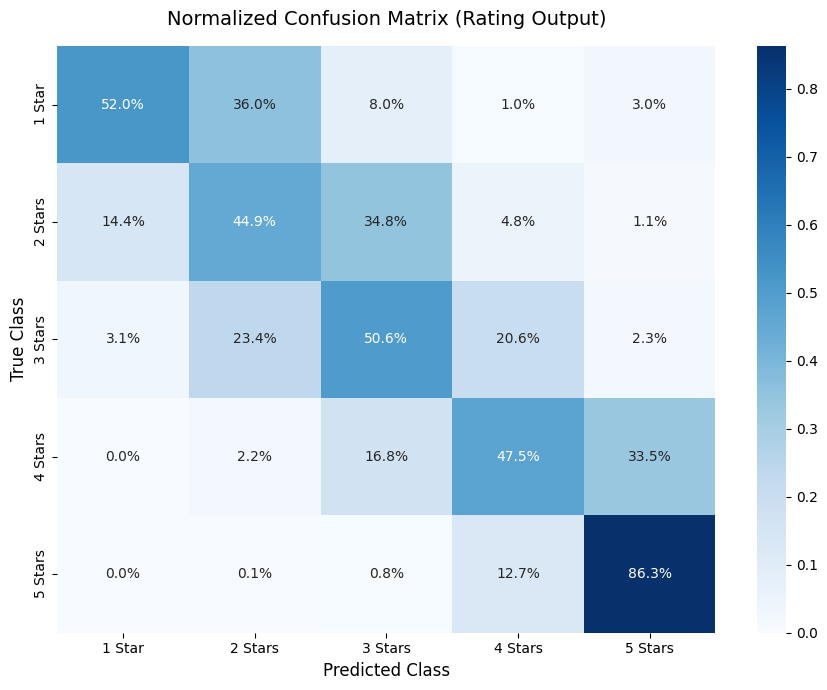


Per-Class Precision, Recall, and F1-Score:

              precision    recall  f1-score   support

      1 Star       0.58      0.52      0.55       100
     2 Stars       0.39      0.45      0.42       187
     3 Stars       0.49      0.51      0.50       350
     4 Stars       0.50      0.47      0.49       600
     5 Stars       0.86      0.86      0.86      1581

    accuracy                           0.70      2818
   macro avg       0.56      0.56      0.56      2818
weighted avg       0.70      0.70      0.70      2818



In [ ]:
val_predictions = model.predict(X_val)
rating_probs = val_predictions[0]

y_pred = np.argmax(rating_probs, axis=1)
y_true = np.argmax(y_val['rating_output'], axis=1)

cm_normalized = confusion_matrix(y_true, y_pred, normalize='true')

class_labels = ['1 Star', '2 Stars', '3 Stars', '4 Stars', '5 Stars']

plt.figure(figsize=(9, 7))
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt='.1%',
    cmap='Blues',
    xticklabels=class_labels,
    yticklabels=class_labels
)
plt.title('Normalized Confusion Matrix (Rating Output)', fontsize=14, pad=15)
plt.xlabel('Predicted Class', fontsize=12)
plt.ylabel('True Class', fontsize=12)
plt.tight_layout()
plt.show()

print("\nPer-Class Precision, Recall, and F1-Score:\n")
print(classification_report(y_true, y_pred, target_names=class_labels))